
===== FEATURES =====
        id  SmO2_baseline     AUC_30s  SmO2_min  dSmO2_max  slope_0_10  \
0   Alexis      70.303775  210.286007     60.68   9.623775   -0.551072   
1  Antoine      77.672467  372.110247     61.89  15.782467   -0.301603   
2   Jinwei      67.972000  155.060200     61.67   6.302000   -0.114292   
3   Victor      70.303775  210.286007     60.68   9.623775   -0.551072   

   tau_SmO2  La_baseline  La_peak  Time_peak_min  Delta_La_peak  
0  7.022233         1.70     16.1            4.0          14.40  
1  5.300891         2.20     17.3            5.0          15.10  
2  0.100000         2.50     13.9            4.0          11.40  
3  7.022233         0.75     13.1            6.0          12.35  

===== MODEL 1 RESULTS =====
Intercept: 3.762521303584867
Coefficients: {'AUC_30s': np.float64(0.0005881165756110716), 'tau_SmO2': np.float64(0.12912615542995481), 'dSmO2_max': np.float64(0.02100079089777733), 'slope_0_10': np.float64(-0.008973685734810869)}
RMSE = 0.707 min
R

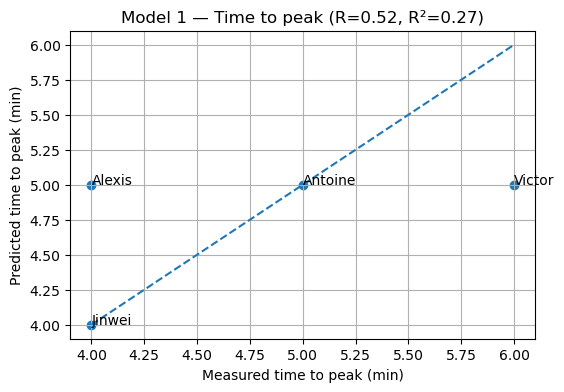

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1) CONFIGURATION
# ==========================================
# CSV files containing SmO2 data
CSV_FILES = {
    "Alexis": "Alexis_wingate.csv",
    "Antoine": "Antoine_wingate.csv",
    "Jinwei": "Jinwei_wingate.csv",
    "Victor": "Victor_wingate.csv",
}

# Excel file containing lactate measurements
XLS_FILE = "Physio_Session2_Wingate.xlsx"
SHEET_NAME = "data"

# Wingate protocol parameters
WINGATE_DURATION = 30      # seconds
BASELINE_BEFORE = 15       # seconds before effort
SLOPE_WINDOW = 10          # early slope window (seconds)

# ==========================================
# 2) HELPER FUNCTIONS
# ==========================================
def parse_sync_to_seconds(sync_val, recording_max=None):
    """
    Convert synchronization value to seconds.

    Handles:
    - numeric values
    - 'mm:ss'
    - 'hh:mm:ss'
    """
    if pd.isna(sync_val):
        raise ValueError("Empty synchronization value")

    try:
        return float(sync_val)
    except Exception:
        pass

    s = str(sync_val).strip()

    if ":" in s:
        parts = [float(x) for x in s.split(":")]
        if len(parts) == 2:
            mm, ss = parts
            return mm * 60 + ss
        elif len(parts) == 3:
            hh, mm, ss = parts
            return hh * 3600 + mm * 60 + ss

    raise ValueError(f"Unknown synchronization format: {sync_val}")


def load_trainred_csv(file_path):
    """
    Load a Train.Red CSV file and return a clean DataFrame with:
    - Time (seconds)
    - SmO2 (%)
    """
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if "Timestamp (seconds passed)" in line and "SmO2" in line:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Header not found in {file_path}")

    df = pd.read_csv(file_path, skiprows=header_idx)
    df.columns = [str(c).strip() for c in df.columns]

    df = df[["Timestamp (seconds passed)", "SmO2"]].copy()
    df.columns = ["Time", "SmO2"]

    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["SmO2"] = pd.to_numeric(df["SmO2"], errors="coerce")

    df = df.dropna(subset=["Time", "SmO2"]).sort_values("Time").reset_index(drop=True)

    return df


def smo2_desat_model(t, A, tau):
    """
    Exponential desaturation model:
    dSmO2(t) = A * (1 - exp(-t/tau))
    """
    return A * (1 - np.exp(-t / tau))


def fit_smo2_tau(win, sm0):
    """
    Fit SmO2 desaturation with an exponential model.

    Returns:
    - A_fit: amplitude of desaturation
    - tau_fit: time constant (seconds)
    """
    t = win["t_rel"].to_numpy(dtype=float)
    y = win["dSmO2"].to_numpy(dtype=float)

    if np.nanmax(y) < 0.5:
        return np.nan, np.nan

    try:
        p0 = [np.nanmax(y), 5.0]
        bounds = ([0.0, 0.1], [50.0, 60.0])

        popt, _ = curve_fit(
            smo2_desat_model,
            t,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=20000
        )

        return float(popt[0]), float(popt[1])

    except Exception:
        return np.nan, np.nan


def extract_wingate_window(sm_df, start_time_s):
    """
    Extract Wingate window and compute SmO2-based features.
    """
    sm = sm_df.copy()

    # --- baseline ---
    baseline_df = sm[(sm["Time"] >= start_time_s - BASELINE_BEFORE) &
                     (sm["Time"] < start_time_s)]

    if baseline_df.empty:
        baseline_df = sm[sm["Time"] < start_time_s]

    if baseline_df.empty:
        raise ValueError("No baseline available")

    sm0 = float(baseline_df["SmO2"].mean())

    # --- Wingate window ---
    win = sm[(sm["Time"] >= start_time_s) &
             (sm["Time"] <= start_time_s + WINGATE_DURATION)].copy()

    if len(win) < 5:
        raise ValueError("Wingate window too short")

    win["t_rel"] = win["Time"] - start_time_s
    win["dSmO2"] = (sm0 - win["SmO2"]).clip(lower=0)

    dt = float(np.mean(np.diff(win["Time"])))
    auc_30 = float(np.sum(win["dSmO2"]) * dt)

    # features
    min_smo2 = float(win["SmO2"].min())
    dmax = float(win["dSmO2"].max())

    early = win[win["t_rel"] <= SLOPE_WINDOW]
    slope = float(np.polyfit(early["t_rel"], early["SmO2"], 1)[0]) if len(early) >= 3 else np.nan

    A_fit, tau_fit = fit_smo2_tau(win, sm0)

    return {
        "sm_window": win,
        "SmO2_baseline": sm0,
        "AUC_30s": auc_30,
        "SmO2_min": min_smo2,
        "dSmO2_max": dmax,
        "slope_0_10": slope,
        "tau_SmO2": tau_fit
    }


def summarize_lactate_subject(lac_subject):
    """
    Extract key lactate variables:
    - baseline
    - peak
    - time to peak
    """
    lac_subject = lac_subject.sort_values("Time")

    la_base = float(lac_subject[lac_subject["Time"] == -1]["[La]"].iloc[0])

    post = lac_subject[lac_subject["Time"] > 0]
    idx_peak = post["[La]"].idxmax()

    la_peak = float(post.loc[idx_peak, "[La]"])
    t_peak = float(post.loc[idx_peak, "Time"])

    return {
        "La_baseline": la_base,
        "La_peak": la_peak,
        "Time_peak_min": t_peak,
        "Delta_La_peak": la_peak - la_base
    }

# ==========================================
# 3) LOAD LACTATE DATA
# ==========================================
lac_all = pd.read_excel(XLS_FILE, sheet_name=SHEET_NAME)
lac_all.columns = [str(c).strip() for c in lac_all.columns]

lac_all["Time"] = pd.to_numeric(lac_all["Time"], errors="coerce")
lac_all["[La]"] = pd.to_numeric(lac_all["[La]"], errors="coerce")

# ==========================================
# 4) FEATURE EXTRACTION
# ==========================================
rows = []

for subject, csv_file in CSV_FILES.items():

    sm = load_trainred_csv(csv_file)

    lac_sub = lac_all[lac_all["Name"].str.lower() == subject.lower()].copy()

    sync_val = lac_sub["Synchro SmO2"].dropna().iloc[0]
    start_time_s = parse_sync_to_seconds(sync_val)

    sm_feat = extract_wingate_window(sm, start_time_s)
    la_feat = summarize_lactate_subject(lac_sub)

    row = {
        "id": subject,
        **{k: v for k, v in sm_feat.items() if k != "sm_window"},
        **la_feat
    }

    rows.append(row)

feat_df = pd.DataFrame(rows)

print("\n===== FEATURES =====")
print(feat_df)

# ==========================================
# 5) MODEL 1 — TIME TO PEAK
# ==========================================
model_cols = ["AUC_30s", "tau_SmO2", "dSmO2_max", "slope_0_10"]

df_m1 = feat_df.dropna(subset=model_cols + ["Time_peak_min"])

X = df_m1[model_cols].to_numpy()
y = df_m1["Time_peak_min"].to_numpy()

model = LinearRegression()
model.fit(X, y)

df_m1["t_peak_pred"] = model.predict(X)

# Force predictions to match actual measurement times
possible_times = np.sort(df_m1["Time_peak_min"].unique())

df_m1["t_peak_pred_discrete"] = [
    possible_times[np.argmin(np.abs(possible_times - t))]
    for t in df_m1["t_peak_pred"]
]

# metrics on discretized predictions
rmse = np.sqrt(mean_squared_error(y, df_m1["t_peak_pred_discrete"]))
r2 = r2_score(y, df_m1["t_peak_pred_discrete"])
r = np.corrcoef(y, df_m1["t_peak_pred_discrete"])[0, 1]

print("\n===== MODEL 1 RESULTS =====")
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(model_cols, model.coef_)))
print(f"RMSE = {rmse:.3f} min")
print(f"R²   = {r2:.3f}")
print(f"R    = {r:.3f}")

# ==========================================
# 6) PLOT
# ==========================================
plt.figure(figsize=(6,4))
plt.scatter(y, df_m1["t_peak_pred_discrete"])

mn = min(y.min(), df_m1["t_peak_pred_discrete"].min())
mx = max(y.max(), df_m1["t_peak_pred_discrete"].max())

plt.plot([mn, mx], [mn, mx], "--")

for _, r_ in df_m1.iterrows():
    plt.annotate(r_["id"], (r_["Time_peak_min"], r_["t_peak_pred_discrete"]))

plt.xlabel("Measured time to peak (min)")
plt.ylabel("Predicted time to peak (min)")
plt.title(f"Model 1 — Time to peak (R={r:.2f}, R²={r2:.2f})")
plt.grid()
plt.show()